In [30]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

# **Load Metadata**

In [31]:
metadata = pd.read_csv('brugada-syndrome/metadata.csv')
print(metadata.iloc[30:35])
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")


    patient_id  basal_pattern  sudden_death  brugada
30      460919              0             0        2
31      461866              0             0        0
32      466796              0             0        0
33      471727              0             0        1
34      478457              0             0        0
Brugada patients: 76


In [32]:
metadata['brugada'] = metadata['brugada'].replace(2, 1)
# metadata = metadata[metadata['brugada'] != 2].reset_index(drop=True)
print(metadata.iloc[30:35])

    patient_id  basal_pattern  sudden_death  brugada
30      460919              0             0        1
31      461866              0             0        0
32      466796              0             0        0
33      471727              0             0        1
34      478457              0             0        0


In [33]:
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


# **Initial Visualization**

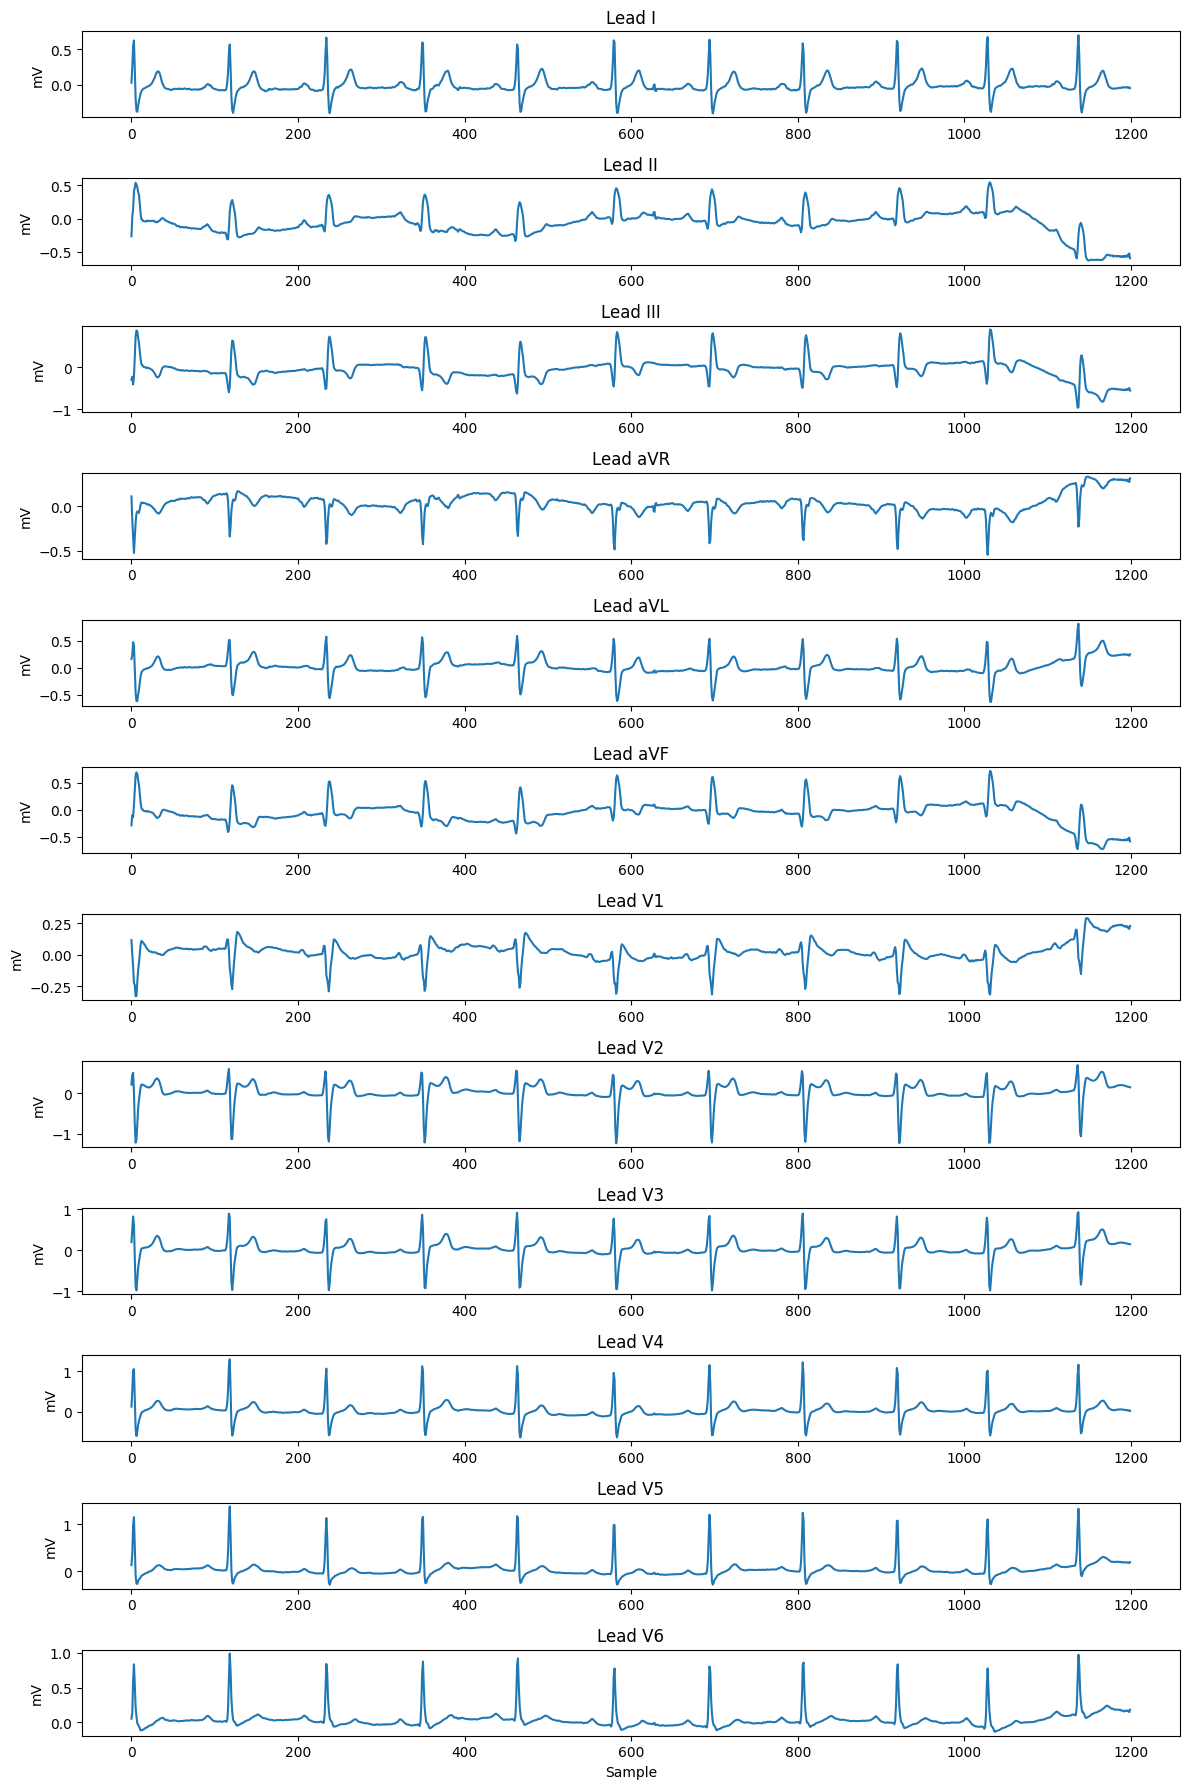

In [34]:
patient_id = '188981'
record = wfdb.rdrecord(f'brugada-syndrome/files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

num_leads = len(lead_names)

plt.figure(figsize=(12, 18))

for i in range(num_leads):
    plt.subplot(num_leads, 1, i + 1)
    plt.plot(signals[:, i])
    plt.title(f'Lead {lead_names[i]}')
    plt.ylabel('mV')

plt.xlabel('Sample')
plt.tight_layout()
plt.show()

# **Filtering**

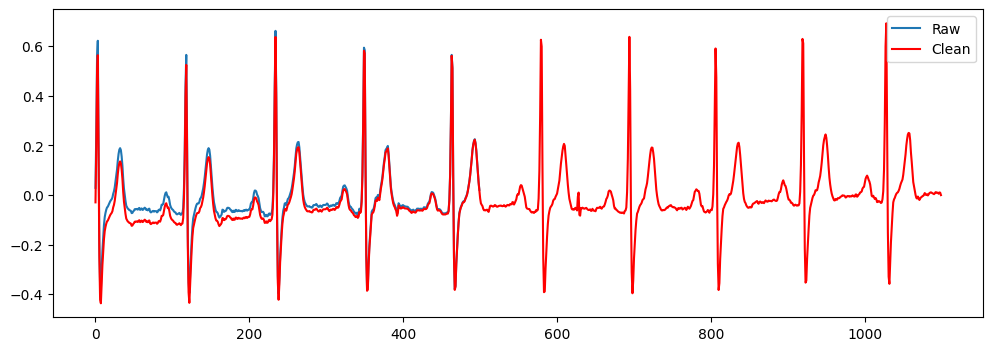

In [35]:
from scipy import signal

def signal_cleaning(raw_data):
    b, a = signal.butter(3, 0.05, btype='highpass', fs=100)
    return signal.filtfilt(b, a, raw_data)

clean_signal = signal_cleaning(signals[:, 0])


plt.figure(figsize=(12, 4))
plt.plot(signals[0:500, 0], label='Raw')
plt.plot(clean_signal[0:1100], label='Clean', color='red')
plt.legend()
plt.show()

# **Normalization**

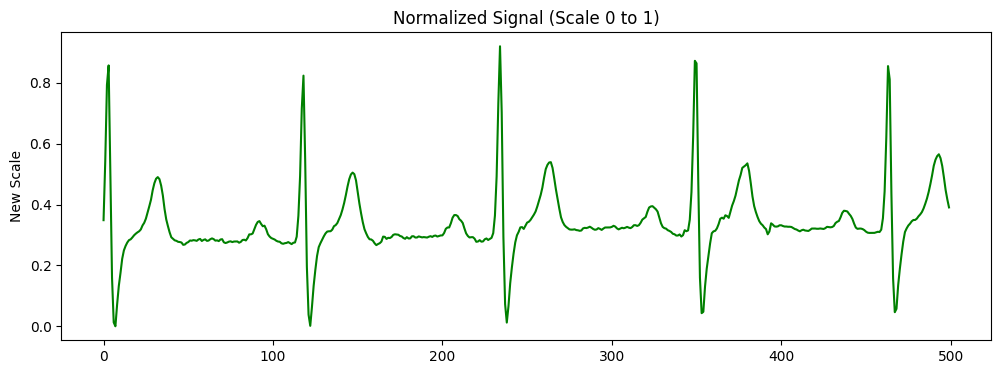

In [36]:
# Normalize
normal_signal = (clean_signal - clean_signal.min()) / (clean_signal.max() - clean_signal.min())


plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0:500], color='green')
plt.title('Normalized Signal (Scale 0 to 1)')
plt.ylabel('New Scale')
plt.show()

# **Peak Detection**

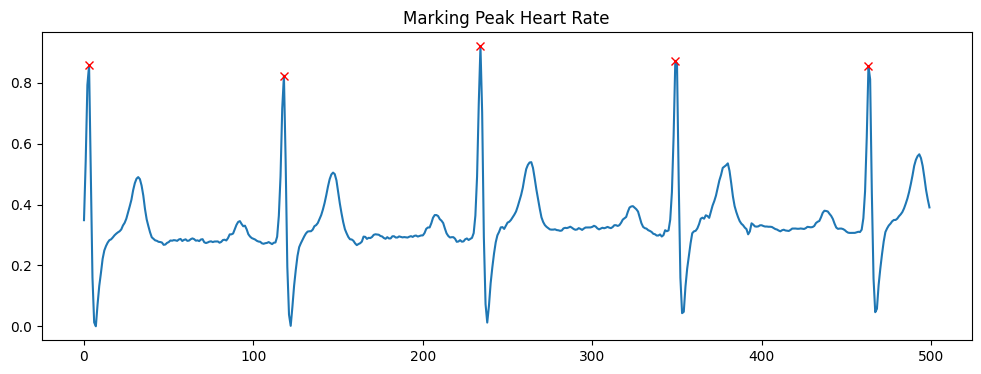

Peak position found: [  3 118 234 349 463]


In [37]:
from scipy.signal import find_peaks

# Finding Peak R
peaks, _ = find_peaks(normal_signal, distance=50, height=0.4)

plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0:500])
plt.plot(peaks[peaks < 500], normal_signal[peaks[peaks < 500]], "x", color='red')
plt.title('Marking Peak Heart Rate')
plt.show()

print(f"Peak position found: {peaks[:5]}")

# **Windowing**

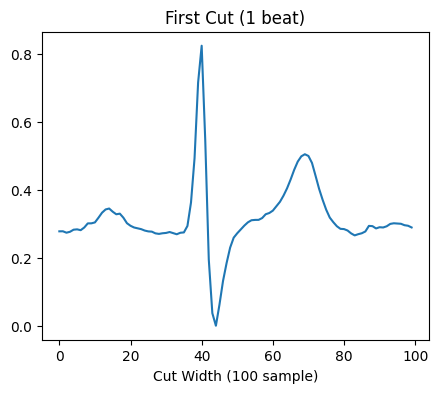

In [38]:
import numpy as np

heartbeat_collection = []
left_width = 40
right_width = 60

# Cutting
for p in peaks:
    if p > left_width and p < (len(normal_signal) - right_width):
        snippet = normal_signal[p - left_width : p + right_width]
        heartbeat_collection.append(snippet)

# Convert to Array
heartbeat_collection = np.array(heartbeat_collection)


plt.figure(figsize=(5, 4))
plt.plot(heartbeat_collection[0])
plt.title('First Cut (1 beat)')
plt.xlabel('Cut Width (100 sample)')
plt.show()

# **Looping**

In [39]:
all_heartbeats = []
all_labels = []
metadata_test = metadata

In [40]:
for index, row in metadata_test.iterrows():
    p_id = str(row['patient_id'])
    is_brugada = row['brugada']
    
    try:
        # 1. Read
        record = wfdb.rdrecord(f'brugada-syndrome/files/{p_id}/{p_id}')
        signal_raw = record.p_signal[:, 0] 
        
        # 2. Filtering
        clean = signal_cleaning(signal_raw) 
        
        # 3. Normalization (Scale 0-1)
        norm = (clean - clean.min()) / (clean.max() - clean.min())
        
        # 4. Peak Detection
        pks, _ = find_peaks(norm, distance=50, height=0.4)
        
        # 5. Windowing
        count_snips = 0
        for p in pks:
            if p > left_width and p < (len(norm) - right_width):
                snip = norm[p - left_width : p + right_width]
                all_heartbeats.append(snip)
                all_labels.append(is_brugada)
                count_snips += 1
        
        print(f"{p_id} Success with {count_snips} Heartbeat.")
                
    except Exception as e:
        print(f"{p_id} Fail: {e}")

188981 Success with 10 Heartbeat.
251972 Success with 12 Heartbeat.
265715 Success with 13 Heartbeat.
267628 Success with 13 Heartbeat.
267630 Success with 7 Heartbeat.
286830 Success with 14 Heartbeat.
287355 Success with 12 Heartbeat.
292220 Success with 13 Heartbeat.
292666 Success with 13 Heartbeat.
304141 Success with 16 Heartbeat.
314397 Success with 11 Heartbeat.
316872 Success with 12 Heartbeat.
317547 Success with 11 Heartbeat.
319150 Success with 11 Heartbeat.
319221 Success with 16 Heartbeat.
325231 Success with 12 Heartbeat.
325966 Success with 10 Heartbeat.
329034 Success with 14 Heartbeat.
329533 Success with 14 Heartbeat.
395553 Success with 11 Heartbeat.
405298 Success with 17 Heartbeat.
406008 Success with 18 Heartbeat.
413267 Success with 14 Heartbeat.
419510 Success with 7 Heartbeat.
419960 Success with 12 Heartbeat.
428031 Success with 14 Heartbeat.
434996 Success with 12 Heartbeat.
438721 Success with 13 Heartbeat.
445953 Success with 11 Heartbeat.
450733 Success w

In [41]:
# Convert to Array
X_test = np.array(all_heartbeats)
y_test = np.array(all_labels)

print(f"Total heartbeat cut (X_test): {X_test.shape}")
print(f"Total label/status (y_test): {y_test.shape}")

Total heartbeat cut (X_test): (4790, 100)
Total label/status (y_test): (4790,)


In [42]:
from scipy.stats import skew, kurtosis

In [43]:
extracted_features = []
left_width = 40
right_width = 60
sample_id_counter = 0

In [44]:
for index, row in metadata.iterrows():
    p_id = str(row['patient_id'])
    is_brugada = row['brugada']

    try:
        record = wfdb.rdrecord(f'brugada-syndrome/files/{p_id}/{p_id}', channels=[1, 6, 7])
        signal_raw = record.p_signal

        norm_signals = np.zeros_like(signal_raw)

        for i in range(3):
            clean = signal_cleaning(signal_raw[:, i])
            # Norm 0-1
            if clean.max() != clean.min():
                norm_signals[:, i] = (clean - clean.min()) / (clean.max() - clean.min())
            else:
                norm_signals[:, i] = clean

        pks, _ = find_peaks(norm_signals[:, 0], distance=50, height=0.4)

        for p in pks:
            if p > left_width and (p + right_width) < len(norm_signals):
                snip = norm_signals[p - left_width : p + right_width, :]

                v1 = snip[:, 1]
                v2 = snip[:, 2]

                v1_feats = {
                    'v1_mean': np.mean(v1), 'v1_std': np.std(v1),
                    'v1_max': np.max(v1), 'v1_min': np.min(v1),
                    'v1_amplitude': np.max(v1) - np.min(v1),
                    'v1_skew': skew(v1), 'v1_kurtosis': kurtosis(v1)
                }

                v2_feats = {
                    'v2_mean': np.mean(v2), 'v2_std': np.std(v2),
                    'v2_max': np.max(v2), 'v2_min': np.min(v2),
                    'v2_amplitude': np.max(v2) - np.min(v2),
                    'v2_skew': skew(v2), 'v2_kurtosis': kurtosis(v2)
                }

                feature_row = {
                    'sample_id': f"SMPL_{sample_id_counter}",
                    'patient_id': p_id,
                    'label': 'Brugada' if is_brugada == 1 else 'Normal',
                    'label_code': is_brugada
                }
                feature_row.update(v1_feats)
                feature_row.update(v2_feats)

                extracted_features.append(feature_row)
                sample_id_counter += 1

    except Exception as e:
        pass

print(f"{len(extracted_features)} heartbeat samples.\n")

4834 heartbeat samples.



# **Dataset Builder**

In [45]:
df_features = pd.DataFrame(extracted_features)

cols_v1 = ['v1_mean', 'v1_std', 'v1_max', 'v1_min', 'v1_amplitude', 'v1_skew', 'v1_kurtosis']
cols_v2 = ['v2_mean', 'v2_std', 'v2_max', 'v2_min', 'v2_amplitude', 'v2_skew', 'v2_kurtosis']

X_v1 = df_features[cols_v1].values
X_v2 = df_features[cols_v2].values
X_v1_v2 = df_features[cols_v1 + cols_v2].values


print(f"X_v1: {X_v1.shape}")
print(f"X_v2: {X_v2.shape}")
print(f"X_v1_v2: {X_v1_v2.shape}")

file_name = "Dataset_IDSC.csv"
df_features.to_csv(file_name, index=False)

X_v1: (4834, 7)
X_v2: (4834, 7)
X_v1_v2: (4834, 14)


In [46]:
from sklearn.model_selection import GroupShuffleSplit
from imblearn.over_sampling import SMOTE

# 1. Feature Selection
X = X_v1_v2
y = df_features['label_code'].values
groups = df_features['patient_id'].values

# 2. OUTER SPLIT: Train+Val vs Test 
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss_outer.split(X, y, groups=groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

# 3. INNER SPLIT: Train vs Validation 
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss_inner.split(X_trainval, y_trainval, groups=groups_trainval))

X_train_raw, X_val = X_trainval[train_idx], X_trainval[val_idx]
y_train_raw, y_val = y_trainval[train_idx], y_trainval[val_idx]

# 4. SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Before SMOTE (Train): {len(y_train_raw)} samples")
print(f"After SMOTE (Train): {len(y_train)} samples (balanced)")
print(f"Validate  (Val): {len(y_val)} samples (Original)")
print(f"Testing (Test): {len(y_test)} samples (Original)")

Before SMOTE (Train): 3102 samples
After SMOTE (Train): 4862 samples (balanced)
Validate  (Val): 774 samples (Original)
Testing (Test): 958 samples (Original)


In [47]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("RANDOM FOREST RESULT")
print(classification_report(y_test, rf_preds))

print("\nXGBOOST RESULT")
print(classification_report(y_test, xgb_preds))

RANDOM FOREST RESULT
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       789
           1       0.48      0.38      0.42       169

    accuracy                           0.82       958
   macro avg       0.68      0.65      0.66       958
weighted avg       0.80      0.82      0.81       958


XGBOOST RESULT
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       789
           1       0.46      0.53      0.50       169

    accuracy                           0.81       958
   macro avg       0.68      0.70      0.69       958
weighted avg       0.82      0.81      0.81       958



In [48]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score
import numpy as np


xgb_probs_val = xgb_model.predict_proba(X_val)[:, 1]


thresholds = np.arange(0.20, 0.80, 0.01)
best_t, best_f2 = 0.5, -1

for t in thresholds:
    preds_t = (xgb_probs_val >= t).astype(int)
    f2 = fbeta_score(y_val, preds_t, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_t = t

print("Best threshold (F2) dari VAL:", round(best_t, 2), "F2:", round(best_f2, 4))


xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds_tuned = (xgb_probs_test >= best_t).astype(int)

print(classification_report(y_test, xgb_preds_tuned, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, xgb_preds_tuned))

Best threshold (F2) dari VAL: 0.2 F2: 0.5512
              precision    recall  f1-score   support

           0     0.9249    0.7022    0.7983       789
           1     0.3454    0.7337    0.4697       169

    accuracy                         0.7077       958
   macro avg     0.6351    0.7179    0.6340       958
weighted avg     0.8227    0.7077    0.7403       958

Confusion matrix:
[[554 235]
 [ 45 124]]


# **Model & Lead Comparison**

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

feature_sets = {
    'V1': X_v1,
    'V2': X_v2,
    'V1+V2': X_v1_v2,
}

y_all = df_features['label_code'].values
groups_all = df_features['patient_id'].values

# Split
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss_outer.split(X_v1_v2, y_all, groups=groups_all))

y_trainval_all = y_all[trainval_idx]
y_test_all = y_all[test_idx]
groups_trainval = groups_all[trainval_idx]

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss_inner.split(X_v1_v2[trainval_idx], y_trainval_all, groups=groups_trainval))

results = []

for feat_name, X_all in feature_sets.items():
    X_trainval = X_all[trainval_idx]
    X_test = X_all[test_idx]

    X_train_raw = X_trainval[train_idx]
    X_val = X_trainval[val_idx]
    y_train_raw = y_trainval_all[train_idx]
    y_val = y_trainval_all[val_idx]
    y_test = y_test_all

    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

    models = [
        ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('XGBoost', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'))
    ]

    for model_name, model in models:
        model.fit(X_train, y_train)

        probs_val = model.predict_proba(X_val)[:, 1]
        probs_test = model.predict_proba(X_test)[:, 1]

        # Threshold default 0.5 (reference)
        preds_default = (probs_test >= 0.5).astype(int)
        acc_def = accuracy_score(y_test, preds_default)
        rec1_def = recall_score(y_test, preds_default, pos_label=1)
        f1_def = f1_score(y_test, preds_default, pos_label=1)

        # Threshold tuning (recall focused)
        thresholds = np.arange(0.20, 0.80, 0.01)
        best_t, best_f2 = 0.5, -1

        for t in thresholds:
            preds_val_t = (probs_val >= t).astype(int)
            f2 = fbeta_score(y_val, preds_val_t, beta=2, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
                best_t = t

        preds_tuned = (probs_test >= best_t).astype(int)
        acc_tuned = accuracy_score(y_test, preds_tuned)
        rec1_tuned = recall_score(y_test, preds_tuned, pos_label=1)
        f1_tuned = f1_score(y_test, preds_tuned, pos_label=1)

        results.append({
            'model': model_name,
            'features': feat_name,
            'threshold_default': 0.5,
            'acc_default': acc_def,
            'recall1_default': rec1_def,
            'f1_1_default': f1_def,
            'threshold_tuned': best_t,
            'acc_tuned': acc_tuned,
            'recall1_tuned': rec1_tuned,
            'f1_1_tuned': f1_tuned
        })

results_df = pd.DataFrame(results)
print(results_df)

          model features  threshold_default  acc_default  recall1_default  \
0  RandomForest       V1                0.5     0.800626         0.633136   
1       XGBoost       V1                0.5     0.776618         0.662722   
2  RandomForest       V2                0.5     0.709812         0.260355   
3       XGBoost       V2                0.5     0.694154         0.295858   
4  RandomForest    V1+V2                0.5     0.815240         0.390533   
5       XGBoost    V1+V2                0.5     0.808977         0.532544   

   f1_1_default  threshold_tuned  acc_tuned  recall1_tuned  f1_1_tuned  
0      0.528395             0.20   0.579332       0.893491    0.428369  
1      0.511416             0.22   0.607516       0.840237    0.430303  
2      0.240437             0.21   0.479123       0.597633    0.288160  
3      0.254453             0.20   0.540710       0.591716    0.312500  
4      0.427184             0.20   0.624217       0.846154    0.442724  
5      0.495868       

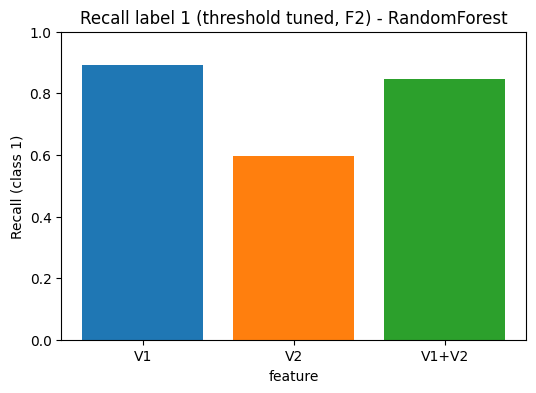

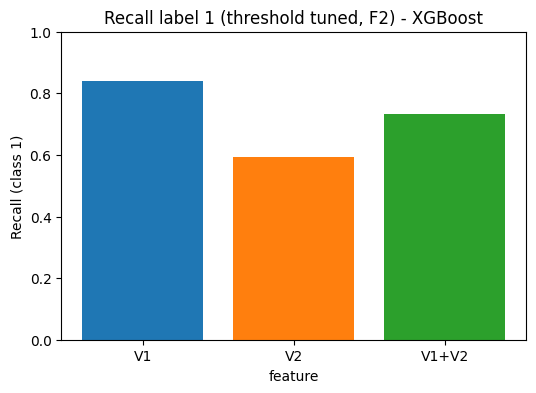

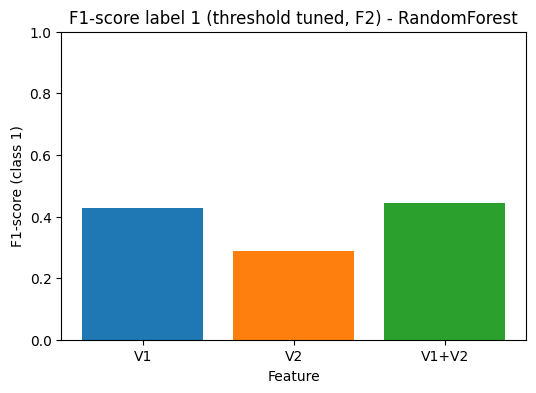

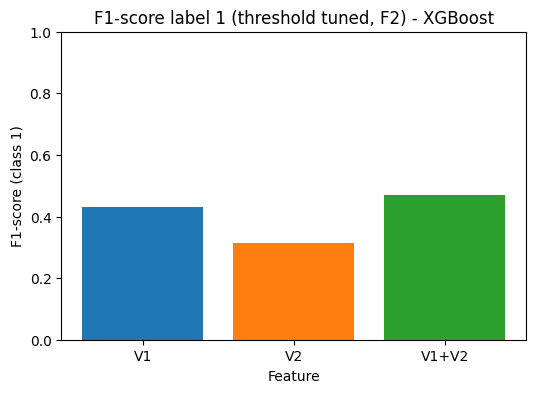

In [51]:
for model_name in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_name]
    plt.figure(figsize=(6, 4))
    plt.bar(sub['features'], sub['recall1_tuned'], color=['tab:blue', 'tab:orange', 'tab:green'])
    plt.ylim(0, 1)
    plt.title(f'Recall label 1 (threshold tuned, F2) - {model_name}')
    plt.ylabel('Recall (class 1)')
    plt.xlabel('feature')
    plt.show()

for model_name in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_name]
    plt.figure(figsize=(6, 4))
    plt.bar(sub['features'], sub['f1_1_tuned'], color=['tab:blue', 'tab:orange', 'tab:green'])
    plt.ylim(0, 1)
    plt.title(f'F1-score label 1 (threshold tuned, F2) - {model_name}')
    plt.ylabel('F1-score (class 1)')
    plt.xlabel('Feature')
    plt.show()